In [1]:
# Project-relative paths: no machine-specific absolute paths are required.
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
for _candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (_candidate / "workspace" / "Source_Data.xlsx").exists():
        PROJECT_ROOT = _candidate
        break
else:
    raise FileNotFoundError(
        "workspace/Source_Data.xlsx was not found. Run the notebook from inside the repository."
    )

WORKSPACE_DIR = PROJECT_ROOT / "workspace"
(WORKSPACE_DIR / "figures").mkdir(parents=True, exist_ok=True)
(WORKSPACE_DIR / "figures_R3").mkdir(parents=True, exist_ok=True)

clean_data_path = WORKSPACE_DIR.as_posix().rstrip("/") + "/"
clean_data_path_yy = clean_data_path
clean_data_path_wzj = clean_data_path
clean_data_path_zzh = clean_data_path
path = clean_data_path
show_dir = clean_data_path

import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt


import warnings
warnings.filterwarnings("ignore")

In [2]:
bands = {
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta1': (12, 24),
    'beta2': (24, 40),
    'low_gamma': (40, 70),
    'high_gamma': (70, 150)
}

band = 'beta1'

In [3]:
feature_pool = {}
ex_features = {}

feature_pool["small_trace_model"] = ["lower_incisor","lip_AKTs","tongue_AKTs","larynx"]
ex_features["small_trace_model"] = ["lower_incisor","lip_AKTs","tongue_AKTs","larynx"]

feature_pool["trace_model"] = ["lower_incisor","upper_lip","lower_lip","tongue_tip","tongue_body","tongue_dorsum","larynx"]
ex_features["trace_model"] = ["lower_incisor","upper_lip","lower_lip","tongue_tip","tongue_body","tongue_dorsum","larynx"]

# Ext. Fig. 7a-d

Ext. Fig. 7a --- SA_shared


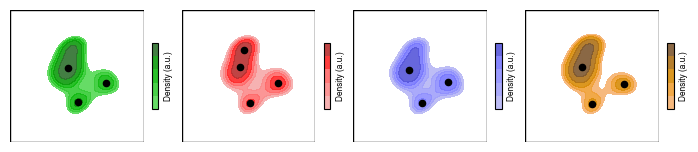

Ext. Fig. 7b --- SI_shared


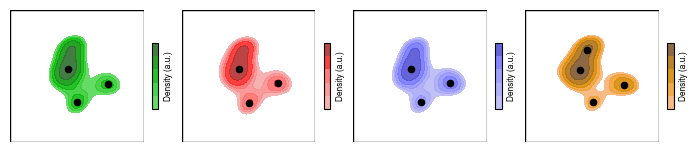

Ext. Fig. 7c --- SA_specific


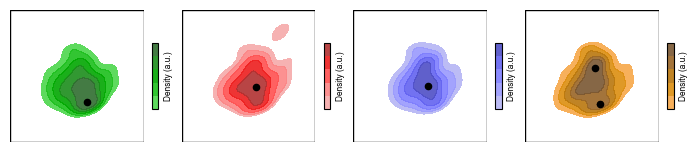

Ext. Fig. 7d --- SI_specific


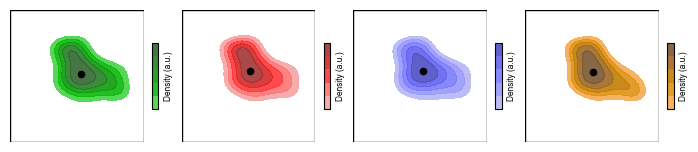

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.ndimage import maximum_filter
from matplotlib.patches import Rectangle

# ---------------- Figure parameters ----------------

plt.rcdefaults()
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

palette = {
    "larynx": "orange",
    "lower_incisor": "g",
    "lip_AKTs": "r",
    "tongue_AKTs": "b"
}

figure_map = {
    "SA_shared":"Ext. Fig. 7a",
    "SI_shared":"Ext. Fig. 7b",
    "SA_specific":"Ext. Fig. 7c",
    "SI_specific":"Ext. Fig. 7d"
}

sheet_map = {
    "SA_shared":"Fig. 4a, Ext. Fig. 7a, 7e",
    "SI_shared":"Fig. 4b, Ext. Fig. 7b, 7e",
    "SA_specific":"Fig. 4c, Ext. Fig. 7c, 7e",
    "SI_specific":"Fig. 4d, Ext. Fig. 7d, 7e"
}

for taskname in figure_map.keys():
    print(figure_map[taskname], '---',taskname)
    # =====================================================
    # Read the Source Data workbook.
    # =====================================================

    plot_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_map[taskname]
    )

    plot_df = plot_df[
        plot_df["value"] > 0.2
    ].copy()

    bw_method = "scott"
    bw_adjust = 0.84 + 100 / len(plot_df)
    weights = "value"
    thresh = 0.5
    levels = 6

    g = sns.FacetGrid(
        plot_df,
        col="label",
        col_wrap=4,
        height=5,
        aspect=1
    )

    g.fig.set_size_inches(7, 1.5)

    # =====================================================
    # Define the plotting function.
    # =====================================================

    def draw_panel(data, **kwargs):

        label = data["label"].iloc[0]

        sns.kdeplot(
            data=data,
            x="x",
            y="y",
            hue="label",
            palette=palette,
            bw_method=bw_method,
            bw_adjust=bw_adjust,
            fill=True,
            thresh=thresh,
            levels=levels,
            alpha=0.9,
            weights=data["value"],
            cbar=True,
            cbar_kws={
                "aspect": 10,
                "shrink": 0.5,
                "pad": 0.05,
                "ticks": [],
                "label": "Density (a.u.)"
            },
            legend=False
        )

        # ===============================
        # Recompute peak values from the Source Data workbook.
        # ===============================

        x = data["x"].values
        y = data["y"].values
        kde_weights = data["value"].values

        kde = gaussian_kde(
            np.vstack([x, y]),
            weights=kde_weights,
            bw_method=bw_method
        )

        original_factor = kde.covariance_factor
        kde.covariance_factor = lambda: original_factor() * bw_adjust
        kde._compute_covariance()

        xmin, xmax = np.min(x), np.max(x)
        ymin, ymax = np.min(y), np.max(y)

        X, Y = np.mgrid[
            xmin:xmax:200j,
            ymin:ymax:200j
        ]

        Z = kde(
            np.vstack([X.ravel(), Y.ravel()])
        ).reshape(X.shape)

        # ---------- Threshold ----------

        Z_flat = Z.ravel()
        Z_sorted = np.sort(Z_flat)
        Z_cdf = np.cumsum(Z_sorted) / np.sum(Z_sorted)

        median_threshold = Z_sorted[
            np.searchsorted(Z_cdf, 0.6)
        ]

        # ---------- Local peaks ----------

        max_filtered = maximum_filter(
            Z,
            size=30
        )

        peaks = (Z == max_filtered)

        peak_values = Z[peaks]

        peak_indices = np.argsort(
            peak_values
        )[-4:]

        peak_positions = np.array(
            np.nonzero(peaks)
        ).T

        top_peaks = peak_positions[
            peak_indices
        ]

        for peak in top_peaks:

            if Z[peak[0], peak[1]] <= median_threshold:
                continue

            plt.scatter(
                X[peak[0], peak[1]],
                Y[peak[0], peak[1]],
                color="k",
                marker="o",
                s=20,
                zorder=20
            )

    # =====================================================
    # Create the plot.
    # =====================================================

    g.map_dataframe(draw_panel)
    g.set_titles("")
    xlim_list = (100, 500)
    ylim_list = (400, 0)

    for ax in g.axes.flat:
        rect = Rectangle(
            (100, 0),
            400,
            400,
            linewidth=1,
            edgecolor="black",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.set_xlim(xlim_list)
        ax.set_ylim(ylim_list)

        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_xlabel("")
        ax.set_ylabel("")

        ax.grid(False)

        for spine in ax.spines.values():
            spine.set_visible(False)

    plt.tight_layout()

    plt.savefig(
        clean_data_path +
        f"/figures_R3/{figure_map[taskname]}.pdf",
        dpi=300,
        transparent=True
    )

    plt.show()

# Fig. 4a-d, Ext. Fig. 7e

Fig. 4a --- SA_shared


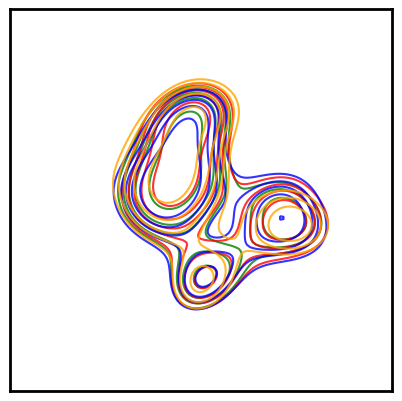

Fig. 4b --- SI_shared


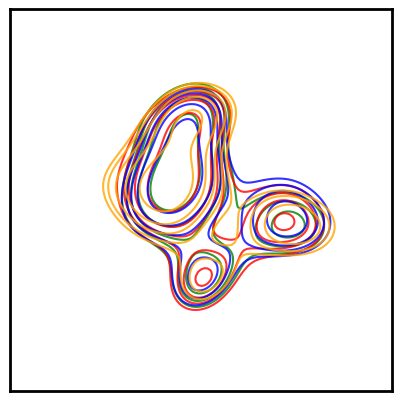

Fig. 4c --- SA_specific


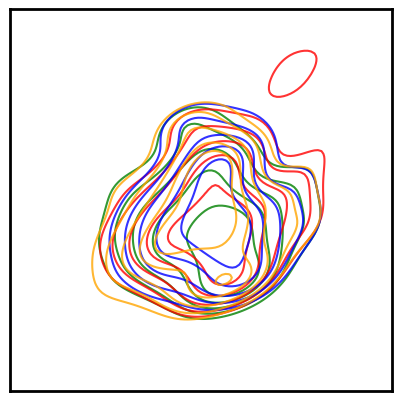

Fig. 4d --- SI_specific


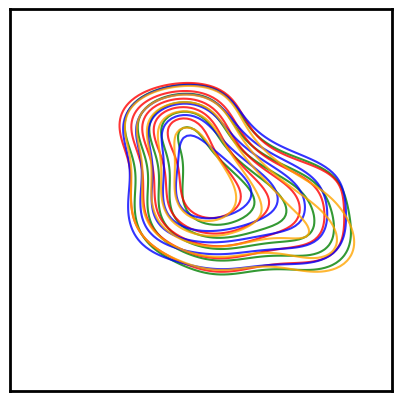

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------- Figure parameters ----------------

plt.rcdefaults()
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

palette = {
    "larynx": "orange",
    "lower_incisor": "g",
    "lip_AKTs": "r",
    "tongue_AKTs": "b"
}

figure_map = {
    "SA_shared":"Fig. 4a",
    "SI_shared":"Fig. 4b",
    "SA_specific":"Fig. 4c",
    "SI_specific":"Fig. 4d"
}

sheet_map = {
    "SA_shared":"Fig. 4a, Ext. Fig. 7a, 7e",
    "SI_shared":"Fig. 4b, Ext. Fig. 7b, 7e",
    "SA_specific":"Fig. 4c, Ext. Fig. 7c, 7e",
    "SI_specific":"Fig. 4d, Ext. Fig. 7d, 7e"
}

for taskname in figure_map:

    print(figure_map[taskname], "---", taskname)

    test_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_map[taskname]
    )

    test_df = test_df[
        test_df["value"] > 0.2
    ].copy()

    # Match the published figure.
    bw_adjust = 0.84 + 100 / len(test_df)

    thresh = 0.5
    levels = 6
    alpha = 0.8

    # ==============================
    # Create the figure.
    # ==============================

    fig, ax = plt.subplots(figsize=(4,4))

    sns.kdeplot(
        data=test_df,
        x="x",
        y="y",
        hue="label",
        weights="value",
        palette=palette,
        thresh=thresh,
        levels=levels,
        alpha=alpha,
        bw_method="scott",
        bw_adjust=bw_adjust,
        common_norm=False,
        ax=ax
    )

    # -------------------
    # Configure the axes.
    # -------------------

    ax.set_xlim(100,500)
    ax.set_ylim(400,0)

    if ax.legend_ is not None:
        ax.legend_.remove()

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_color("black")

    plt.tight_layout()

    plt.savefig(
        clean_data_path +
        f"/figures_R3/{figure_map[taskname]}_contour.pdf",
        dpi=300,
        transparent=True
    )

    plt.show()

Fig. 4a, Ext. Fig. 7e --- SA_shared


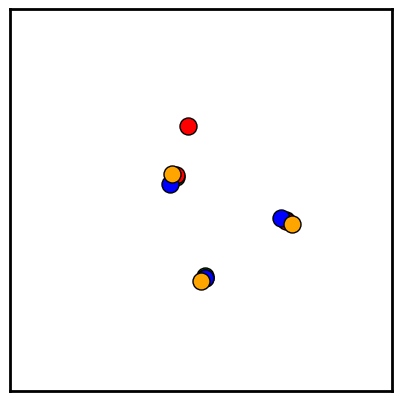

Fig. 4b, Ext. Fig. 7e --- SI_shared


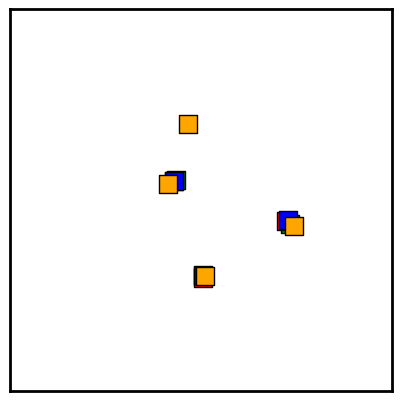

Fig. 4c, Ext. Fig. 7e --- SA_specific


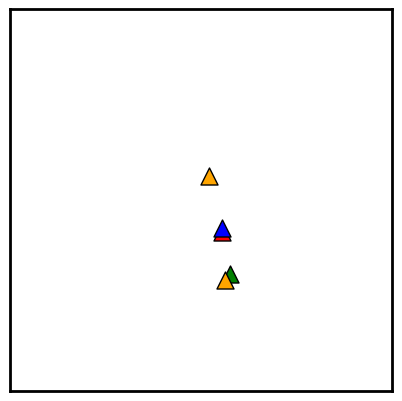

Fig. 4d, Ext. Fig. 7e --- SI_specific


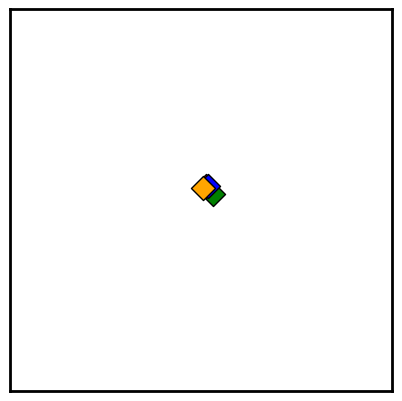

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde
from scipy.ndimage import maximum_filter

# =====================================================
# Define the figure parameters.
# =====================================================

plt.rcdefaults()
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

bw_method = "scott"

color_set = {
    "larynx": "orange",
    "lower_incisor": "g",
    "lip_AKTs": "r",
    "tongue_AKTs": "b"
}

task_marker_map = {
    "SA_shared": "o",
    "SI_shared": "s",
    "SA_specific": "^",
    "SI_specific": "D",
}

figure_map = {
    "SA_shared": "Fig. 4a, Ext. Fig. 7e",
    "SI_shared": "Fig. 4b, Ext. Fig. 7e",
    "SA_specific": "Fig. 4c, Ext. Fig. 7e",
    "SI_specific": "Fig. 4d, Ext. Fig. 7e"
}

sheet_map = {
    "SA_shared":"Fig. 4a, Ext. Fig. 7a, 7e",
    "SI_shared":"Fig. 4b, Ext. Fig. 7b, 7e",
    "SA_specific":"Fig. 4c, Ext. Fig. 7c, 7e",
    "SI_specific":"Fig. 4d, Ext. Fig. 7d, 7e"
}

order = [
    "lower_incisor",
    "lip_AKTs",
    "tongue_AKTs",
    "larynx"
]

# =====================================================
# Create the plot.
# =====================================================

for taskname in figure_map.keys():

    print(figure_map[taskname], "---", taskname)

    marker = task_marker_map[taskname]

    test_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet_map[taskname]
    )

    test_df = test_df[test_df["value"] > 0.2].copy()

    bw_adjust = 0.84 + 100 / len(test_df)

    fig, ax = plt.subplots(figsize=(4, 4))

    # =====================================================
    # Calculate peak values.
    # =====================================================

    for label in order:

        data = test_df[test_df["label"] == label]

        if len(data) == 0:
            continue

        x = data["x"].values
        y = data["y"].values
        value = data["value"].values

        kde = gaussian_kde(
            np.vstack([x, y]),
            weights=value,
            bw_method=bw_method
        )

        original_factor = kde.covariance_factor

        kde.covariance_factor = lambda: original_factor() * bw_adjust

        kde._compute_covariance()

        xmin, xmax = np.min(x), np.max(x)
        ymin, ymax = np.min(y), np.max(y)

        X, Y = np.mgrid[
            xmin:xmax:200j,
            ymin:ymax:200j
        ]

        Z = kde(
            np.vstack([X.ravel(), Y.ravel()])
        ).reshape(X.shape)

        # ---------------- Threshold ----------------

        Z_flat = Z.ravel()

        Z_sorted = np.sort(Z_flat)

        Z_cdf = np.cumsum(Z_sorted) / np.sum(Z_sorted)

        median_threshold = Z_sorted[
            np.searchsorted(Z_cdf, 0.6)
        ]

        # ---------------- Local peaks ----------------

        max_filtered = maximum_filter(
            Z,
            size=30
        )

        peaks = (Z == max_filtered)

        peak_values = Z[peaks]

        peak_indices = np.argsort(
            peak_values
        )[-4:]

        peak_positions = np.array(
            np.nonzero(peaks)
        ).T

        top_peaks = peak_positions[
            peak_indices
        ]

        # ---------------- Draw the panels ----------------

        for peak in top_peaks:

            if Z[peak[0], peak[1]] <= median_threshold:
                continue

            ax.scatter(
                X[peak[0], peak[1]],
                Y[peak[0], peak[1]],
                c=color_set[label],
                marker=marker,
                s=150,
                edgecolor="black",
                linewidth=1,
                alpha=1
            )

    # =====================================================
    # Configure the axes.
    # =====================================================

    ax.set_xlim(100, 500)
    ax.set_ylim(400, 0)

    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")

    ax.grid(False)

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(2)

    plt.tight_layout()

    plt.savefig(
        clean_data_path +
        f"/figures_R3/{figure_map[taskname]}_peaks.pdf",
        dpi=300,
        transparent=True
    )

    plt.show()

# Fig. 4e-f

Global max z-score = 7.1269


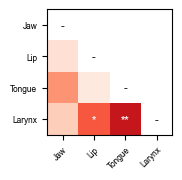

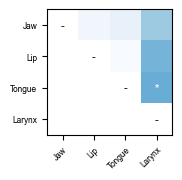

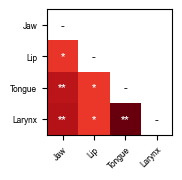

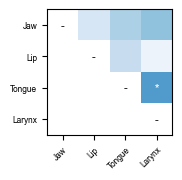

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

poa_list = ['Jaw', 'Lip', 'Tongue', 'Larynx']
n = len(poa_list)

# --------------------------------------------------
# Map each figure panel to its Source Data worksheet.
# --------------------------------------------------

task_sheet_map = {
    "SA_shared":   "Fig. 4e lower triangle",
    "SI_shared":   "Fig. 4e upper triangle",
    "SA_specific": "Fig. 4f lower triangle",
    "SI_specific": "Fig. 4f upper triangle",
}

figure_name_map = task_sheet_map

# --------------------------------------------------
# Determine the global maximum z score.
# Use a shared color scale across panels.
# --------------------------------------------------

global_max = 0

for sheet in task_sheet_map.values():

    df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet
    )

    global_max = round(
        max(global_max, df["zscore"].max()),
        4
    )

print("Global max z-score =", global_max)

# --------------------------------------------------
# Draw each figure panel.
# --------------------------------------------------

for taskname in task_sheet_map.keys():

    filtered_df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=task_sheet_map[taskname]
    )

    ED_matrix = np.full((n, n), np.nan)
    p_matrix = np.full((n, n), np.nan)
    symbol_matrix = np.full((n, n), "", dtype=object)

    # -----------------------------
    # Build the matrix.
    # -----------------------------

    for i, label1 in enumerate(poa_list):

        for j, label2 in enumerate(poa_list):

            if i == j:
                continue

            row = filtered_df[
                (
                    (filtered_df["label1"] == label1)
                    &
                    (filtered_df["label2"] == label2)
                )
                |
                (
                    (filtered_df["label1"] == label2)
                    &
                    (filtered_df["label2"] == label1)
                )
            ]

            if row.empty:
                continue

            ED_matrix[i, j] = row["zscore"].iloc[0]
            p_matrix[i, j] = row["p_bonf"].iloc[0]
            symbol_matrix[i, j] = row["symbol"].iloc[0]

    # -----------------------------
    # Normalize the matrix.
    # -----------------------------

    ED_norm = ED_matrix / global_max

    # -----------------------------
    # Retain one triangle of the symmetric matrix.
    # -----------------------------

    if "lower" in task_sheet_map[taskname]:

        for i in range(n):
            for j in range(n):
                if j > i:
                    ED_norm[i, j] = np.nan

        cmap = plt.cm.Reds

    else:

        for i in range(n):
            for j in range(n):
                if j < i:
                    ED_norm[i, j] = np.nan

        cmap = plt.cm.Blues

    import copy as _copy

    cmap = _copy.copy(cmap)
    cmap.set_bad(alpha=0)

    # -----------------------------
    # Create the plot.
    # -----------------------------

    fig, ax = plt.subplots(figsize=(1.8, 1.8))

    im = ax.imshow(
        ED_norm,
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    ax.set_xticks(np.arange(n))
    ax.set_yticks(np.arange(n))

    ax.set_xticklabels(poa_list)
    ax.set_yticklabels(poa_list)

    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor"
    )

    # -----------------------------
    # Add significance symbols.
    # -----------------------------

    textcolor = "whitesmoke"

    for i in range(n):

        for j in range(n):

            if i == j:

                ax.text(
                    j,
                    i,
                    "-",
                    ha="center",
                    va="center",
                    fontsize=8
                )

                continue

            if (
                "lower" in task_sheet_map[taskname]
                and
                i > j
            ):

                symbol = symbol_matrix[i, j]

                if symbol not in ["", "ns"]:

                    ax.text(
                        j,
                        i,
                        symbol,
                        ha="center",
                        va="center",
                        color=textcolor,
                        fontsize=8,
                        fontweight="bold"
                    )

            if (
                "upper" in task_sheet_map[taskname]
                and
                i < j
            ):

                symbol = symbol_matrix[i, j]

                if symbol not in ["", "ns"]:

                    ax.text(
                        j,
                        i,
                        symbol,
                        ha="center",
                        va="center",
                        color=textcolor,
                        fontsize=8,
                        fontweight="bold"
                    )

    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    for spine in ax.spines.values():
        spine.set_visible(True)

    plt.tight_layout()

    plt.savefig(
        clean_data_path +
        f"/figures_R3/{figure_name_map[taskname]}.pdf",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()

7.1269


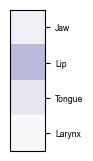

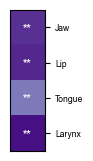

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6.2

sheet_map = {
    "shared": "Fig. 4e right bar",
    "specific": "Fig. 4f right bar",
}

# Use a shared color scale across panels if needed.
global_max = 7.1269
print(global_max)

for sheet in sheet_map.values():

    df = pd.read_excel(
        clean_data_path + "/Source_Data.xlsx",
        sheet_name=sheet
    )

    ED_matrix = df["zscore"].to_numpy().reshape(4,1)
    symbol_matrix = df["symbol"].to_numpy().reshape(4,1)

    ED_norm = ED_matrix / global_max

    fig, ax = plt.subplots(figsize=(1.6,1.6))

    cmap = plt.cm.Purples

    im = ax.imshow(
        ED_norm,
        cmap=cmap,
        vmin=0,
        vmax=1
    )

    ax.set_xticks([])

    ax.set_yticks(np.arange(4))
    ax.set_yticklabels(df["POA"])

    ax.yaxis.set_ticks_position("right")
    ax.yaxis.set_label_position("right")

    for i in range(4):

        symbol = symbol_matrix[i,0]

        if symbol not in ["", "ns"]:

            ax.text(
                0,
                i,
                symbol,
                ha="center",
                va="center",
                color="whitesmoke",
                fontsize=8,
                fontweight="bold"
            )

    plt.tight_layout()

    plt.savefig(
        clean_data_path +
        f"/figures_R3/{sheet}.pdf",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()

In [9]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 6

# Define the three color maps.
cmap_dict = {
    "Reds": plt.cm.Reds,
    "Blues": plt.cm.Blues,
    "Purples": plt.cm.Purples
}

for cmap_name, cmap in cmap_dict.items():

    fig, ax = plt.subplots(figsize=(0.10, 1.5))

    norm = plt.Normalize(vmin=0, vmax=1)

    cb = plt.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=cmap),
        cax=ax,
        orientation="vertical"
    )

    # Hide tick marks.
    cb.set_ticks([])
    cb.set_label("")
    cb.ax.tick_params(
        left=False,
        right=False,
        labelleft=False
    )

    plt.tight_layout()

    plt.savefig(
        clean_data_path + f"/figures_R3/Fig. 4f_bar_{cmap_name}.pdf",
        dpi=300,
        transparent=True,
        bbox_inches="tight"
    )

    plt.show()
    plt.close(fig)

# Fig. 2j

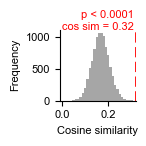

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# Plot exclusively from the Source Data workbook.
# =====================================================
model = "trace_model"
sta = "delta_r2"

feature_names = feature_pool[model]

test_list = [
    f"{model}_{i}_{sta}"
    for i in feature_names
]

source_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Fig. 2j"
)

perm_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Fig. 2j permutation"
)

# Reconstruct the matrices.

o_arr = source_df[
    [f"SA_shared_{f}" for f in feature_names]
].values

c_arr = source_df[
    [f"SI_shared_{f}" for f in feature_names]
].values

perm_distribution = perm_df[
    "Permutation cosine similarity"
].values

cosine_sim = cosine_similarity(
    o_arr.reshape(1,-1),
    c_arr.reshape(1,-1)
)[0,0]

p_value = (
    perm_distribution >= cosine_sim
).mean()

# =====================================================
# Create the plot.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(1.5,1.5))

ax.hist(
    perm_distribution,
    bins=30,
    color="gray",
    alpha=0.7
)

ax.axvline(
    cosine_sim,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")

if p_value < 0.0001:
    plt.text(cosine_sim-0.01, plt.ylim()[1] * 1, f'p < 0.0001\ncos sim = {cosine_sim:.2f}', color='red',ha='right')
else:
    plt.text(cosine_sim-0.01, plt.ylim()[1] * 1, f'p = {p_value}\ncos sim = {cosine_sim:.2f}', color='red',ha='right')

plt.tight_layout()

plt.savefig(
    clean_data_path+
    "/figures_R3/Fig. 2j.pdf",
    dpi=300,
    transparent=True
)

plt.show()

# Fig. 2f-g

['UL', 'LI', 'TB', 'TD', 'L', 'LL', 'TT']


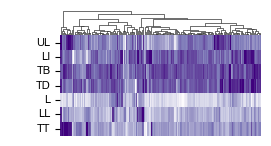

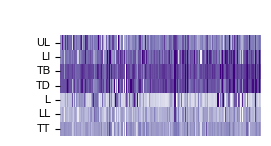

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# =====================================================
# Define the analysis parameters.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

model = "trace_model"

vmin = 0
vmax = 0.8
cmap = "Purples"

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df_SA = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 2f"
)

source_df_SI = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 2g"
)

# =====================================================
# Recover the matrices from the tabular data.
# =====================================================

o_arr = source_df_SA.values
c_arr = source_df_SI.values

# =====================================================
# Define the feature labels.
# =====================================================

akt_map_dict = {
    "lower_incisor": "LI",
    "upper_lip": "UL",
    "lower_lip": "LL",
    "tongue_tip": "TT",
    "tongue_body": "TB",
    "tongue_dorsum": "TD",
    "larynx": "L"
}

labels = [
    akt_map_dict.get(i, i)
    for i in feature_pool[model]
]

# =====================================================
# Perform hierarchical clustering.
# Cluster the electrodes while preserving the feature order.
# =====================================================

col_linkage = linkage(
    pdist(o_arr),
    method="ward"
)

row_linkage = linkage(
    pdist(o_arr.T),
    method="ward"
)

col_order = dendrogram(
    col_linkage,
    no_plot=True
)["leaves"]

row_order = dendrogram(
    row_linkage,
    no_plot=True
)["leaves"]

o_arr_clustered = o_arr[np.ix_(col_order, row_order)]
c_arr_clustered = c_arr[np.ix_(col_order, row_order)]

o_arr_clustered = o_arr_clustered.T
c_arr_clustered = c_arr_clustered.T

labels_clustered = [labels[i] for i in row_order]
print(labels_clustered)

# =====================================================
# Plot SA_shared for Fig. 2f.
# =====================================================

g = sns.clustermap(
    o_arr_clustered,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=True,
    method="ward",
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Fig. 2f.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Plot SI_shared for Fig. 2g.
# Reuse the electrode order from SA_shared.
# =====================================================

g = sns.clustermap(
    c_arr_clustered,
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=False,
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Fig. 2g.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# Fig. 2k

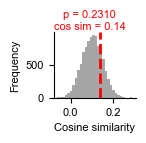

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# Plot exclusively from the Source Data workbook.
# =====================================================
model = "trace_model"
sta = "delta_r2"

feature_names = feature_pool[model]

source_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Fig. 2k"
)

perm_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Fig. 2k permutation"
)

# Reconstruct the matrices.

o_arr = source_df[
    [f"SA_specific_{f}" for f in feature_names]
].values

c_arr = source_df[
    [f"SI_specific_{f}" for f in feature_names]
].values

perm_distribution = perm_df[
    "Permutation cosine similarity"
].values

cosine_sim = cosine_similarity(
    o_arr.reshape(1,-1),
    c_arr.reshape(1,-1)
)[0,0]

p_value = (
    perm_distribution >= cosine_sim
).mean()

# =====================================================
# Create the plot.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(1.5,1.5))

ax.hist(
    perm_distribution,
    bins=30,
    color="gray",
    alpha=0.7
)

ax.axvline(
    cosine_sim,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")


if p_value < 0.0001:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1, f'p < 0.0001\ncos sim = {cosine_sim:.2f}', color='red',ha='right')
else:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1.05, f'p = {p_value:.4f}\ncos sim = {cosine_sim:.2f}', color='red',ha='center')

plt.tight_layout()

plt.savefig(
    clean_data_path+
    "/figures_R3/Fig. 2k.pdf",
    dpi=300,
    transparent=True
)

plt.show()

# Fig. 2h-i

['UL', 'LL', 'L', 'LI', 'TT', 'TB', 'TD']


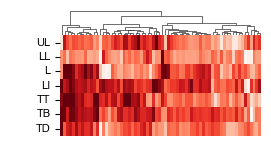

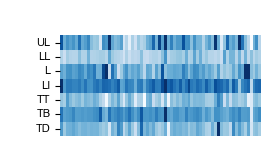

In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram

# =====================================================
# Define the analysis parameters.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

model = "trace_model"

vmin = 0
vmax = 0.8
# cmap = "Purples"

# =====================================================
# Read the Source Data workbook.
# =====================================================

source_df_SA = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 2h"
)

source_df_SI = pd.read_excel(
    clean_data_path + "/Source_Data.xlsx",
    sheet_name="Fig. 2i"
)

# =====================================================
# Recover the matrices from the tabular data.
# =====================================================

o_arr = source_df_SA.values
c_arr = source_df_SI.values

# =====================================================
# Define the feature labels.
# =====================================================

akt_map_dict = {
    "lower_incisor": "LI",
    "upper_lip": "UL",
    "lower_lip": "LL",
    "tongue_tip": "TT",
    "tongue_body": "TB",
    "tongue_dorsum": "TD",
    "larynx": "L"
}

labels = [
    akt_map_dict.get(i, i)
    for i in feature_pool[model]
]

# =====================================================
# Perform hierarchical clustering.
# Cluster the electrodes while preserving the feature order.
# =====================================================

col_linkage = linkage(
    pdist(o_arr),
    method="ward"
)

row_linkage = linkage(
    pdist(o_arr.T),
    method="ward"
)

col_order = dendrogram(
    col_linkage,
    no_plot=True
)["leaves"]

row_order = dendrogram(
    row_linkage,
    no_plot=True
)["leaves"]

o_arr_clustered = o_arr[np.ix_(col_order, row_order)]
c_arr_clustered = c_arr[np.ix_(col_order, row_order)]

o_arr_clustered = o_arr_clustered.T
c_arr_clustered = c_arr_clustered.T

labels_clustered = [labels[i] for i in row_order]
print(labels_clustered)

# =====================================================
# Plot SA_specific for Fig. 2h.
# =====================================================

g = sns.clustermap(
    o_arr_clustered,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=True,
    method="ward",
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Fig. 2h.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# Plot SI_specific for Fig. 2i.
# Reuse the electrode order from SA_shared.
# =====================================================

g = sns.clustermap(
    c_arr_clustered,
    cmap="Blues",
    vmin=vmin,
    vmax=vmax,
    figsize=(3, 1.5),
    row_cluster=False,
    col_cluster=False,
    yticklabels=labels_clustered,
    xticklabels=False,
    cbar_pos=None
)

ax = g.ax_heatmap

ax.yaxis.set_ticks_position("left")
ax.yaxis.set_label_position("left")

ax.set_yticklabels(
    labels_clustered,
    rotation=0,
    ha="right"
)

plt.savefig(
    clean_data_path +
    "/figures_R3/Fig. 2i.pdf",
    dpi=300,
    transparent=True,
    bbox_inches="tight"
)

plt.show()

# Ext. Fig. 7g

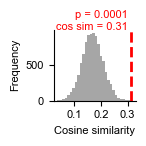

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# Plot exclusively from the Source Data workbook.
# =====================================================
model = "small_trace_model"
sta = "delta_r2"

feature_names = feature_pool[model]

source_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 7g"
)

perm_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 7g permutation"
)

# Reconstruct the matrices.

o_arr = source_df[
    [f"SA_shared_{f}" for f in feature_names]
].values

c_arr = source_df[
    [f"SI_shared_{f}" for f in feature_names]
].values

perm_distribution = perm_df[
    "Permutation cosine similarity"
].values

cosine_sim = cosine_similarity(
    o_arr.reshape(1,-1),
    c_arr.reshape(1,-1)
)[0,0]

p_value = (
    perm_distribution >= cosine_sim
).mean()

# =====================================================
# Create the plot.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(1.5,1.5))

ax.hist(
    perm_distribution,
    bins=30,
    color="gray",
    alpha=0.7
)

ax.axvline(
    cosine_sim,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")

if p_value < 0.0001:
    plt.text(cosine_sim-0.01, plt.ylim()[1] * 1, f'p < 0.0001\ncos sim = {cosine_sim:.2f}', color='red',ha='right')
else:
    plt.text(cosine_sim-0.01, plt.ylim()[1] * 1, f'p = {p_value}\ncos sim = {cosine_sim:.2f}', color='red',ha='right')

plt.tight_layout()

plt.savefig(
    clean_data_path+
    "/figures_R3/Ext. Fig. 7g.pdf",
    dpi=300,
    transparent=True
)

plt.show()

# Ext. Fig. 7h

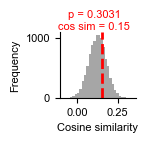

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity

# =====================================================
# Plot exclusively from the Source Data workbook.
# =====================================================
model = "small_trace_model"
sta = "delta_r2"

feature_names = feature_pool[model]

source_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 7h"
)

perm_df = pd.read_excel(
    clean_data_path+"/Source_Data.xlsx",
    sheet_name="Ext. Fig. 7h permutation"
)

# Reconstruct the matrices.

o_arr = source_df[
    [f"SA_specific_{f}" for f in feature_names]
].values

c_arr = source_df[
    [f"SI_specific_{f}" for f in feature_names]
].values

perm_distribution = perm_df[
    "Permutation cosine similarity"
].values

cosine_sim = cosine_similarity(
    o_arr.reshape(1,-1),
    c_arr.reshape(1,-1)
)[0,0]

p_value = (
    perm_distribution >= cosine_sim
).mean()

# =====================================================
# Create the plot.
# =====================================================

plt.rcdefaults()

plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.size"] = 8

fig, ax = plt.subplots(figsize=(1.5,1.5))

ax.hist(
    perm_distribution,
    bins=30,
    color="gray",
    alpha=0.7
)

ax.axvline(
    cosine_sim,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlabel("Cosine similarity")
ax.set_ylabel("Frequency")


if p_value < 0.0001:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1, f'p < 0.0001\ncos sim = {cosine_sim:.2f}', color='red',ha='right')
else:
    plt.text(cosine_sim-0.05, plt.ylim()[1] * 1.05, f'p = {p_value:.4f}\ncos sim = {cosine_sim:.2f}', color='red',ha='center')

plt.tight_layout()

plt.savefig(
    clean_data_path+
    "/figures_R3/Ext. Fig. 7h.pdf",
    dpi=300,
    transparent=True
)

plt.show()